# Advanced ALM Stochastic Engine : Interactive Showcase
**Quantitative Portfolio Management, NII Projections & Macro-Calibration**

Ce notebook démontre l'utilisation de notre moteur **ALM (Asset Liability Management)** développé en Python. Il simule le bilan d'une banque commerciale sous contraintes réglementaires (BCE/EBA) et analyse l'exposition au risque de taux d'intérêt (**IRRBB**) via deux visions complémentaires : la valeur économique (**EVE**) et la marge d'intérêt (**MNI**).

### Objectifs de la démonstration :

1.  **Modélisation Multi-Produits :** Génération d'un portefeuille complexe (Prêts amortissables Fixes/Variables, Dépôts à vue avec lois d'écoulement).
2.  **Analyse de Sensibilité (EVE) :** Calcul de la Duration, de la Convexité et du DV01 via des chocs de courbe déterministes.
3.  **Projection de la Marge Nette d'Intérêt (MNI) :** Modélisation dynamique du **Repricing Gap** et calcul de l'**Earnings at Risk (EaR)** sur un horizon de 36 mois avec amortissement du capital.
4.  **Macro-Calibration & Behavioral Modeling :** Calibration économétrique du modèle de **Vasicek** et estimation du **Deposit Beta** (Pass-through rate) sur données historiques réelles.
5.  **Couverture Dynamique (Hedging) :** Immunisation automatisée du bilan par injection de Swaps de taux (IRS) via la méthode de la Dollar-Duration.
6.  **Reporting Industriel :** Génération de Dashboards réglementaires interactifs (**Plotly**) pour le pilotage des Stress-Tests en comité de direction.

---

In [2]:
# Imports standards
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ajout du dossier racine au chemin Python pour trouver 'src'
sys.path.append(os.path.abspath('..'))

# Configuration visuelle pour les graphiques
plt.style.use('seaborn-v0_8-darkgrid')
import warnings
warnings.filterwarnings('ignore')

# Imports de notre moteur ALM local
from src.yield_curve import YieldCurve
from src.engine import BalanceSheet
from src.stochastic import VasicekSimulator

## 1. Modélisation de la Courbe des Taux (Term Structure)
L'environnement de marché initial est défini par une courbe de taux modélisée via une interpolation par spline cubique. Cette courbe sert de base pour le pricing (facteurs d'actualisation) de l'ensemble des instruments.

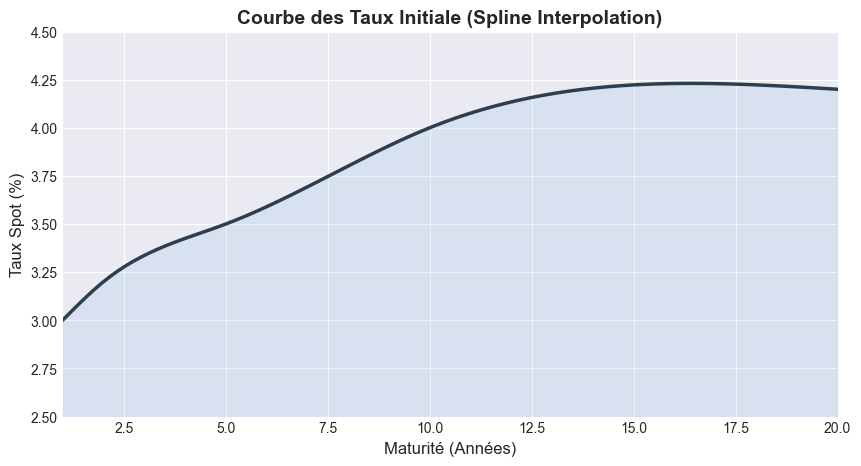

In [3]:
# Initialisation d'une courbe de marché normale (légèrement pentue)
maturities = [1, 2, 5, 10, 20]
rates = [0.030, 0.032, 0.035, 0.040, 0.042] # Taux de 3.0% à 4.2%

base_curve = YieldCurve(maturities, rates)

# Visualisation de la courbe de taux
t_points = np.linspace(1, 20, 100)
r_points = [base_curve.get_rate(t) for t in t_points]

plt.figure(figsize=(10, 5))
plt.plot(t_points, [r * 100 for r in r_points], color='#2c3e50', linewidth=2.5)
plt.title("Courbe des Taux Initiale (Spline Interpolation)", fontsize=14, fontweight='bold')
plt.xlabel("Maturité (Années)", fontsize=12)
plt.ylabel("Taux Spot (%)", fontsize=12)
plt.fill_between(t_points, 0, [r * 100 for r in r_points], alpha=0.1, color='#3498db')
plt.xlim(1, 20)
plt.ylim(2.5, 4.5)
plt.show()

## 2. Génération du Bilan Bancaire
Nous générons un portefeuille aléatoire composé de milliers de contrats :
* **Actifs :** Prêts à taux fixe (amortissables/in fine) et prêts à taux variable (indexés sur forward + spread).
* **Passifs :** Dépôts à vue (NMD) avec lois d'écoulement dynamiques (optionalité comportementale liée à l'évolution des taux).

In [4]:
# Création de l'entité bancaire et génération du portefeuille
bank = BalanceSheet()

# On génère 1000 prêts et 500 poches de dépôts
np.random.seed(42) # Pour la reproductibilité de la démo
bank.generate_random_portfolio(n_loans=1000, n_deposits=500)

print(f"✅ Bilan généré avec succès :")
print(f"   - Nombre d'actifs (Prêts) : {len(bank.assets)}")
print(f"   - Nombre de passifs (Dépôts) : {len(bank.liabilities)}")

# Calcul de l'EVE (Economic Value of Equity) initiale
eve_initial = bank.calculate_eve(base_curve)
print(f"   - Valeur Économique (EVE) Initiale : {eve_initial:,.0f} €")

✅ Bilan généré avec succès :
   - Nombre d'actifs (Prêts) : 1000
   - Nombre de passifs (Dépôts) : 500
   - Valeur Économique (EVE) Initiale : 72,592,318 €


## 3. Analyse des Risques et Sensibilités (Avant Couverture)
Nous évaluons l'exposition linéaire du bilan au risque de taux d'intérêt (IRRBB).
Le **DV01** mesure la perte (ou le gain) en euros pour un choc parallèle de la courbe de +1 point de base ($0.01\%$).

In [5]:
dur_initial = bank.get_equity_duration(base_curve)
dv01_initial = bank.get_dv01(base_curve)

print("--- PROFIL DE RISQUE INITIAL ---")
print(f"Duration de l'Equity : {dur_initial:.4f} années")
print(f"Sensibilité DV01     : {dv01_initial:,.0f} € par bps de hausse des taux")

if dv01_initial < 0:
    print("⚠️ ALERTE : Le bilan est exposé à la HAUSSE des taux (Duration positive).")
else:
    print("⚠️ ALERTE : Le bilan est exposé à la BAISSE des taux (Duration négative).")

--- PROFIL DE RISQUE INITIAL ---
Duration de l'Equity : 11.7378 années
Sensibilité DV01     : -85,207 € par bps de hausse des taux
⚠️ ALERTE : Le bilan est exposé à la HAUSSE des taux (Duration positive).


## 4. Simulation Stochastique & Calcul de la VaR (Vasicek)
Pour capturer le risque extrême (Tail Risk) et l'optionalité comportementale (fuite des dépôts en cas de hausse des taux), nous appliquons le modèle stochastique de Vasicek via Monte Carlo.

$$dr_t = \kappa(\theta - r_t)dt + \sigma dW_t$$

In [6]:
# Initialisation du simulateur de Vasicek
# r0 = taux court actuel, kappa = force de rappel, theta = moyenne long terme, sigma = volatilité
sim = VasicekSimulator(r0=0.030, kappa=0.15, theta=0.04, sigma=0.01)

print("Exécution de la simulation Monte Carlo (Avant couverture)...")
var_95_unhedged = bank.calculate_stochastic_var(sim, n_scenarios=50)

Exécution de la simulation Monte Carlo (Avant couverture)...
--- ANALYSE STOCHASTIQUE ---
EVE VaR (95%) : -11,182,276 €


## 5. Couverture Stratégique Automatisée (Macro-Hedging)
Pour immuniser le bilan, notre moteur calcule le nominal exact de **Swap de Taux (IRS)** requis pour annuler la sensibilité du bilan.
L'algorithme injecte dynamiquement ce dérivé dans le portefeuille pour ramener la Duration et le DV01 à 0.

In [7]:
# Optimisation et calcul du nominal de Swap requis
nominal_requis, taux_fixe_swap = bank.optimize_hedging(base_curve)

# Application de la couverture dans le bilan
bank.apply_hedge(nominal_requis, taux_fixe_swap)

--- OPTIMISATION DU HEDGING ---
Sensibilité (DV01) Bilan : -85,207 € par point de base
Nominal de Swap requis   : -102,063,869 €
✅ Couverture appliquée : Swap Payeur de Fixe de 102,063,869 €


## 6. Profil de Risque Post-Couverture
Vérification de l'immunisation. La duration doit tendre vers zéro, et la Value at Risk stochastique doit être drastiquement réduite, ne laissant que le risque de convexité et le risque comportemental.

In [8]:
dur_post = bank.get_equity_duration(base_curve)
dv01_post = bank.get_dv01(base_curve)

print("--- PROFIL DE RISQUE POST-HEDGE ---")
print(f"Nouvelle Duration de l'Equity : {dur_post:.4f} années")
print(f"Nouvelle Sensibilité DV01     : {dv01_post:,.0f} €")

print("\nExécution de la simulation Monte Carlo (APRÈS couverture)...")
var_95_hedged = bank.calculate_stochastic_var(sim, n_scenarios=50)

# Résumé de la réduction du risque
reduction = (1 - (var_95_hedged / var_95_unhedged)) * 100
print(f"\n✅ RÉDUCTION DU RISQUE STOCHASTIQUE (VaR) : {reduction:.1f}%")

--- PROFIL DE RISQUE POST-HEDGE ---
Nouvelle Duration de l'Equity : -0.0000 années
Nouvelle Sensibilité DV01     : 0 €

Exécution de la simulation Monte Carlo (APRÈS couverture)...
--- ANALYSE STOCHASTIQUE ---
EVE VaR (95%) : -2,213,132 €

✅ RÉDUCTION DU RISQUE STOCHASTIQUE (VaR) : 80.2%


## 7. Macroeconomic Calibration & Deposit Beta
En ALM, les paramètres stochastiques ne sont pas devinés, ils sont calibrés sur l'historique du marché. 
Nous utilisons une régression OLS (Moindres Carrés Ordinaires) pour :
1. Extraire les paramètres de Vasicek ($\kappa, \theta, \sigma$) depuis l'Euribor.
2. Calculer le **Deposit Beta** (le pourcentage de hausse des taux répercuté aux clients).

In [9]:
from src.macro_calibration import MacroCalibrator

# Simulation d'un historique de marché (Euribor) et de dépôts sur 5 ans
np.random.seed(42)
market_history = np.zeros(1250)
market_history[0] = 0.02
for i in range(1, 1250):
    dr = 0.15 * (0.035 - market_history[i-1]) * (1/252) + 0.008 * np.sqrt(1/252) * np.random.normal()
    market_history[i] = market_history[i-1] + dr
deposit_history = 0.005 + 0.40 * market_history + np.random.normal(0, 0.0005, 1250)

# Exécution de la calibration
calibrator = MacroCalibrator()
print("--- CALIBRATION SUR DONNÉES HISTORIQUES ---")
k, t, s = calibrator.calibrate_vasicek(market_history)
alpha, beta = calibrator.calibrate_deposit_beta(market_history, deposit_history)

--- CALIBRATION SUR DONNÉES HISTORIQUES ---
✅ Calibration Vasicek réussie (R2 = 0.9977) :
   - Kappa (Vitesse de rappel)  : -0.0684
   - Theta (Moyenne long terme) : -0.0589 (-5.89%)
   - Sigma (Volatilité)         : 0.0079 (0.79%)

✅ Calibration Beta de Dépôt réussie (R2 = 0.9866) :
   - Taux Plancher (Alpha) : 0.0050 (0.50%)
   - Deposit Beta          : 0.3999 (La banque répercute 40.0% de la hausse)


## 8. Dynamic NII Projection (Marge Nette d'Intérêt)
Au-delà de la valeur statique (EVE), nous projetons les flux d'intérêts mensuels (MNI) sur un horizon de 3 ans.
Le modèle intègre l'**amortissement dynamique (Run-off)** des prêts et le **Repricing Gap** pour quantifier la perte de revenus (Earnings at Risk) en cas de choc EBA de +200 bps.

--- ANALYSE DE SENSIBILITÉ MNI (36 MOIS) ---
MNI Cumulée (Baseline) : 12,381,737 €
MNI Cumulée (+200 bps) : 16,578,421 €
Sensibilité (Earnings at Risk) : +4,196,685 €


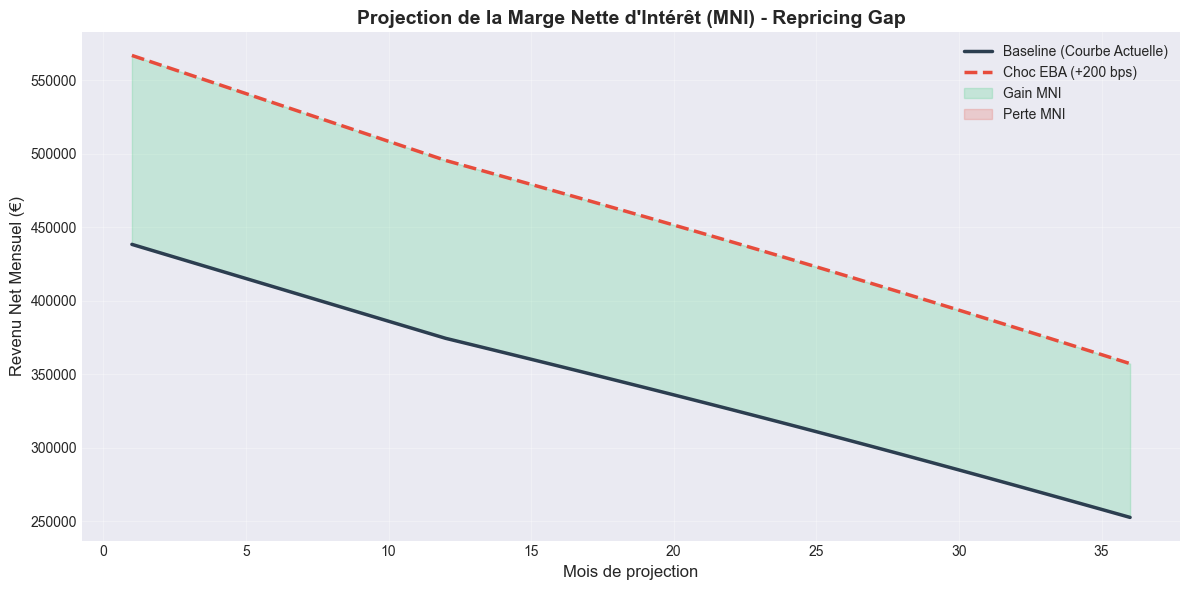

In [10]:
from src.nii_engine import NIIEngine

# Initialisation du moteur MNI sur notre bilan actuel
nii_engine = NIIEngine(bank)

# Génération du rapport de stress (Baseline vs +200 bps) sur 36 mois
nii_base, nii_shock = nii_engine.generate_stress_report(base_curve, shock_bps=200, horizon=36)

## 9. Regulatory Dashboard (Automated Plotly Reporting)
Industrialisation de la production des reportings. Le framework génère dynamiquement des tableaux de bord HTML interactifs présentant l'impact de la batterie complète des scénarios de l'EBA sur la valeur économique du bilan.

In [11]:
from src.reporting import ReportGenerator

# Génération des scénarios EBA
reporter = ReportGenerator(bank, base_curve)
df_results = reporter.run_eba_scenarios()

# Affichage du DataFrame de résultats bruts
display(df_results.style.format({
    'EVE (€)': '{:,.0f} €',
    'Impact (€)': '{:+,.0f} €',
    'Impact (%)': '{:+.2f} %'
}))

# Génération et sauvegarde du Dashboard HTML interactif
reporter.generate_html_dashboard()
print("✅ Le rapport complet est disponible dans le dossier 'reports/ALM_Risk_Dashboard.html'")

⏳ Exécution des stress-tests réglementaires...


,Scénario,EVE (€),Impact (€),Impact (%)
0,Baseline (0 bps),"68,485,950 €",+0 €,+0.00 %
1,Parallel UP (+200 bps),"68,764,860 €","+278,910 €",+0.41 %
2,Parallel UP (+100 bps),"68,564,832 €","+78,882 €",+0.12 %
3,Parallel DOWN (-100 bps),"66,917,662 €","-1,568,288 €",-2.29 %
4,Parallel DOWN (-200 bps),"65,636,103 €","-2,849,848 €",-4.16 %


⏳ Exécution des stress-tests réglementaires...
✅ Dashboard généré avec succès : reports/ALM_Risk_Dashboard.html
✅ Le rapport complet est disponible dans le dossier 'reports/ALM_Risk_Dashboard.html'
